# Final Project: Predicting Tumor Status 

By Kavan Wills, Magnus Lie, & Isra Abudiab

Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

# Question

Using breast cancer data, can we predict whether a tumor is malignant or benign? Benign tumors are non-cancerous, slow-growing, encapsulated masses that do not spread to other body parts. Malignant tumors are cancerous, fast-growing, and invade nearby tissues or metastasize to distant organs. So, identifying which is which is important for the participant's health! In this project, we will use linear regression, decision trees, and finally Random Forest for prediction. We will begin with exploratory data analysis, then move to modelling, and finally to our conclusions. Let's get started!

# Exploratory Data Analysis

Our data contains ten real-valued features that are computed for each cell nucleus: adius (mean of distances from center to points on the perimeter), texture (standard deviation of gray-scale values), perimeter, area, smoothness (local variation in radius lengths), compactness (perimeter^2 / area - 1.0), concavity (severity of concave portions of the contour), concave points (number of concave portions of the contour), symmetry, and fractal dimension ("coastline approximation" - 1). The dataset is mostly clean aside from one column with missing values, so the main thing we will do is logarithmic transformations for columns that need scaling.

In [331]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, precision_recall_curve

In [332]:
df = pd.read_csv("Cancer.csv")

In [333]:
df=df.drop(columns=["id","Unnamed: 32"])

In [334]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [335]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [336]:
# Logarithmic Transformations or sqrt transforms(we will use a model with this data changed and one without the data transformed)

def sqrtAndLogTransformations(df):
    df.loc[:,"concavity_mean"] = np.sqrt(df.loc[:,"concavity_mean"])
    df.loc[:,"concave points_mean"] = np.sqrt(df.loc[:,"concave points_mean"])
    df.loc[:,"radius_se"] = np.sqrt(df.loc[:,"radius_se"])
    df.loc[:,"perimeter_se"] = np.log(df.loc[:,"perimeter_se"])
    df.loc[:,"area_se"] = np.log(df.loc[:,"area_se"])
    df.loc[:,"smoothness_se"] = np.sqrt(df.loc[:,"smoothness_se"])
    df.loc[:,"concavity_se"] = np.sqrt(df.loc[:,"concavity_se"])
    df.loc[:,"concave points_se"] = np.sqrt(df.loc[:,"concave points_se"])
    df.loc[:,"fractal_dimension_se"] = np.sqrt(df.loc[:,"fractal_dimension_se"])
    df.loc[:,"area_worst"] = np.log(df.loc[:,"area_worst"])
    return df

df = sqrtAndLogTransformations(df)

In [337]:
X= df.iloc[:,1:]
y= df.iloc[:,0]

In [338]:
print(X)
print(y)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     compactness_mean  concavity_mean  concave points_mean  sym

In [339]:
log_reg_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[("numeric", StandardScaler(), X.columns)],
        remainder='passthrough')),
    ('classifier', LogisticRegression(random_state=42, solver="lbfgs"))
])

In [340]:
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[("numeric", StandardScaler(), X.columns)],
        remainder='passthrough')),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=5))
])

In [341]:
random_forest_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[("numeric", StandardScaler(), X.columns)],
        remainder='passthrough')),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=200,
    #max_depth=5,
    #min_samples_leaf=5,
    bootstrap=True, 
    oob_score=True,
    #class_weight=True
    ))
])

# Methods

In [342]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [343]:
logReg = log_reg_pipeline.fit(X_train, y_train)

logReg_preds = logReg.predict(X_test)
logReg_preds_odds = logReg.predict_proba(X_test)

In [344]:
dt = dt_pipeline.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_preds_odds = dt.predict_proba(X_test)

In [345]:
# Since we use boot strapping we don't fit on just train data
rf = random_forest_pipeline.fit(X, y)

# Evaluation

In [346]:
# Confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, logReg_preds, labels=["M","B"])
cm_logReg = pd.DataFrame(cm, index=["M","B"], columns=["M","B"])

print(f"Logistic Regression Confusion Matrix(Actual=Vertical, Predicted=Horizontal)\n{cm_logReg}")

# Confusion matrix for Decision Tree
cm = confusion_matrix(y_test, dt_preds, labels=["M","B"])
cm_decisionTree = pd.DataFrame(cm, index=["M","B"], columns=["M","B"])

print(f"Decision Tree Confusion Matrix(Actual=Vertical, Predicted=Horizontal)\n{cm_decisionTree}")

Logistic Regression Confusion Matrix(Actual=Vertical, Predicted=Horizontal)
    M   B
M  34   3
B   2  75
Decision Tree Confusion Matrix(Actual=Vertical, Predicted=Horizontal)
    M   B
M  31   6
B   3  74


In [347]:
# TPR AND FPR for Logistic Regression
TPR_log = cm_logReg.loc["M", "M"] / cm_logReg.loc["M"].sum()
FPR_log = cm_logReg.loc["B", "M"] / cm_logReg.loc["B"].sum()

print(f"Logistic Regression\nTPR : {TPR_log}\nFPR : {FPR_log}")

# TPR AND FPR for Decision Tree
TPR_dt = cm_decisionTree.loc["M", "M"] / cm_decisionTree.loc["M"].sum()
FPR_dt = cm_decisionTree.loc["B", "M"] / cm_decisionTree.loc["B"].sum()

print(f"Decision Tree\nTPR : {TPR_dt}\nFPR : {FPR_dt}")

Logistic Regression
TPR : 0.918918918918919
FPR : 0.025974025974025976
Decision Tree
TPR : 0.8378378378378378
FPR : 0.03896103896103896


In [348]:
print(f"Logistic Regression:\n{classification_report(y_test, logReg_preds, target_names=["B","M"])}")
print(f"Decision Tree:\n{classification_report(y_test, dt_preds, target_names=["B","M"])}")

Logistic Regression:
              precision    recall  f1-score   support

           B       0.96      0.97      0.97        77
           M       0.94      0.92      0.93        37

    accuracy                           0.96       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Decision Tree:
              precision    recall  f1-score   support

           B       0.93      0.96      0.94        77
           M       0.91      0.84      0.87        37

    accuracy                           0.92       114
   macro avg       0.92      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



Logistic Regression AUC: 0.9863109863109863


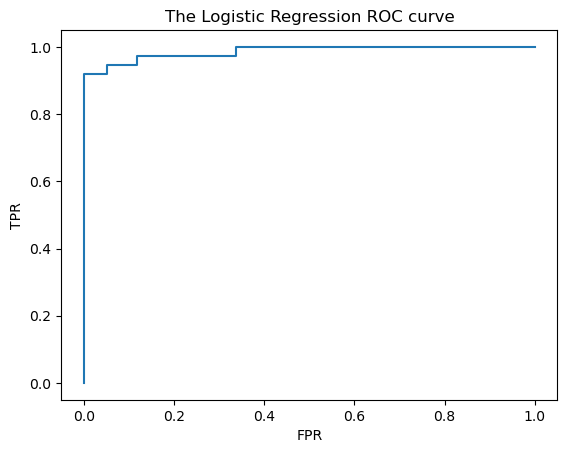

Decision Tree AUC: 0.8941733941733941


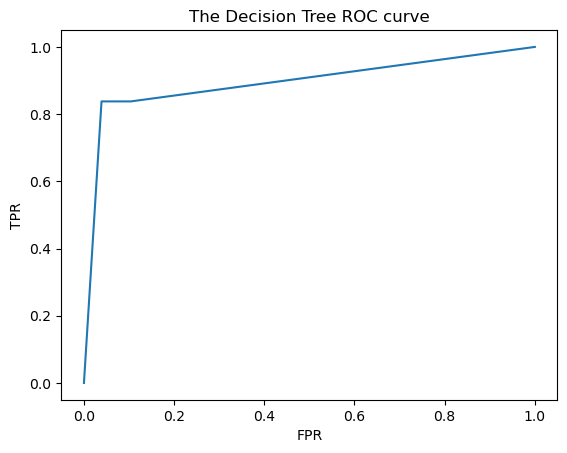

In [349]:
#Define the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logReg_preds_odds[:,1], pos_label="M")
#Grab the AUC
roc_auc = auc(fpr, tpr)
print(f"Logistic Regression AUC: {roc_auc}")

#Plot the ROC Graph to see visually how it looks
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("The Logistic Regression ROC curve")
plt.show()

#Define the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, dt_preds_odds[:,1], pos_label="M")
#Grab the AUC
roc_auc = auc(fpr, tpr)
print(f"Decision Tree AUC: {roc_auc}")

#Plot the ROC Graph to see visually how it looks
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("The Decision Tree ROC curve")
plt.show()

ALL OF THIS UNDER IS JUST CODE I WROTE BEFORE, I WILL EDIT IT TO FIT WITH THIS PROJECT

In [350]:
#Grab the precision_recall_curve to calculate precision and recall which we can graph later
precision, recall, thresholds = precision_recall_curve(results['target'], results['prob_poisonous'], pos_label="p")

#Calculate said AUC
roc_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {roc_auc}")

#Plot the precision-recall roc graph
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("The Precision-Recall ROC curve")
plt.show()

NameError: name 'results' is not defined

# Conclusions

# Team Contribution